# Black Box Optimisation Capstone Project

# Week 1: Black Box Functions EDA (2D → 8D)
Goals:
1. Explore low-dimensional functions (2D–3D) with scatterplots.
2. Explore medium- to high-dimensional functions (4D–8D) using correlations, pairwise plots, and output analysis.
3. Identify influential input dimensions and trends to guide Bayesian Optimizati
on.



In [2]:
# ===========================
# 1. Import Libraries
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [3]:
import os

# Base directory
base_dir = r"C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data"

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # --------------------
    # 1. Build file paths
    # --------------------
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # --------------------
    # 2. Load .npy arrays
    # --------------------
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)

    # --------------------
    # 3. Reshape to 2D if needed
    # --------------------
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # --------------------
    # 4. Create column names (temporary)
    # --------------------
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]

    # --------------------
    # 5. Concatenate inputs + outputs
    # --------------------
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)

    # --------------------
    # 6. Rename columns in-place
    # --------------------
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)

    # --------------------
    # 7. Store in dictionary
    # --------------------
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


## 3. Basic Summary Statistics
- Check min, max, mean, std for each dimension and output.


In [6]:
import pandas as pd

print("=== Missing Data Summary for All Functions ===\n")

for name, df in functions_data.items():
    print(f"Dataset: {name}")
    
    # Count missing values per column
    missing_per_col = df.isnull().sum()
    total_missing = missing_per_col.sum()
    
    print("Missing values per column:")
    display(missing_per_col)
    
    print(f"Total missing values in {name}: {total_missing}\n")


=== Missing Data Summary for All Functions ===

Dataset: f1
Missing values per column:


X1    0
X2    0
y1    0
dtype: int64

Total missing values in f1: 0

Dataset: f2
Missing values per column:


X1    0
X2    0
y1    0
dtype: int64

Total missing values in f2: 0

Dataset: f3
Missing values per column:


...

Total missing values in f6: 0

Dataset: f7
Missing values per column:


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
y1    0
dtype: int64

Total missing values in f7: 0

Dataset: f8
Missing values per column:


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
y1    0
dtype: int64

Total missing values in f8: 0



In [40]:
for name, df in functions_data.items():
    print(f"\n=== {name} Full Data ===")
    display(df)  # Display the entire DataFrame


=== f1 Full Data ===


,X1,X2,y1
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48



=== f2 Full Data ===


,X1,X2,y1
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205



=== f3 Full Data ===


...

,X1,X2,X3,X4,X5,y1
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116



=== f7 Full Data ===


,X1,X2,X3,X4,X5,X6,y1
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565



=== f8 Full Data ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [21]:
for name, df in functions_data.items():
    print(f"\n=== {name} Summary Statistics ===")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





=== f1 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,10.0,0.548817,0.259160,0.082507,3.421622e-01,6.122216e-01,7.191223e-01,8.838898e-01
X2,10.0,0.539519,0.296007,0.078723,2.994206e-01,6.318902e-01,7.554695e-01,8.798981e-01
y1,10.0,-0.000361,0.001140,-0.003606,-1.566820e-91,6.793724e-80,7.903833e-47,7.710875e-16



=== f2 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,10.0,0.538513,0.237188,0.142699,0.365854,0.516180,0.693427,0.877791
X2,10.0,0.487930,0.320245,0.028698,0.233014,0.517012,0.756760,0.926564
y1,10.0,0.230674,0.237555,-0.065624,0.027016,0.229792,0.388938,0.611205



=== f3 Summary Statistics ===


...

,count,mean,std,min,25%,50%,75%,max
X1,20.0,0.547765,0.303015,0.021735,0.254775,0.624060,0.773685,0.957740
X2,20.0,0.562570,0.283617,0.114404,0.304453,0.617630,0.813638,0.931871
X3,20.0,0.467217,0.315292,0.016523,0.165252,0.435052,0.714228,0.978806
X4,20.0,0.534433,0.280259,0.045613,0.329066,0.621691,0.710318,0.961656
X5,20.0,0.423745,0.297199,0.004911,0.111981,0.506517,0.628985,0.892819
y1,20.0,-1.495390,0.460664,-2.571170,-1.713639,-1.446370,-1.227829,-0.714265



=== f7 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,30.0,0.510852,0.303946,0.057896,0.203026,0.542122,0.783687,0.942451
X2,30.0,0.395803,0.252579,0.011813,0.197771,0.387701,0.543137,0.924694
X3,30.0,0.389609,0.314041,0.003635,0.075285,0.318555,0.662281,0.924571
X4,30.0,0.512819,0.311966,0.073659,0.220787,0.459767,0.826525,0.961017
X5,30.0,0.467201,0.314733,0.014944,0.190704,0.457732,0.719142,0.998655
X6,30.0,0.484704,0.269343,0.051100,0.276764,0.552544,0.707072,0.951014
y1,30.0,0.219607,0.307294,0.002701,0.017954,0.078631,0.274431,1.364968



=== f8 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,40.0,0.534609,0.310676,0.009077,0.302376,0.532770,0.792979,0.985945
X2,40.0,0.472150,0.309706,0.003419,0.206189,0.540389,0.712416,0.973980
X3,40.0,0.515970,0.282440,0.022929,0.306074,0.488684,0.732348,0.998885
X4,40.0,0.430449,0.261479,0.009043,0.179607,0.470111,0.663788,0.902986
X5,40.0,0.468951,0.281380,0.009649,0.236969,0.411933,0.722449,0.986902
X6,40.0,0.460126,0.277376,0.022113,0.245246,0.409715,0.706965,0.990244
X7,40.0,0.579196,0.257913,0.035909,0.428796,0.596949,0.770316,0.992914
X8,40.0,0.506720,0.281347,0.041956,0.294756,0.525116,0.729496,0.988755
y1,40.0,7.815274,0.958966,5.592193,7.257810,7.889150,8.490139,9.598482


## 4. Correlation Analysis

- Pearson Correlation → captures linear relationships
  . Spearman correlation → captures monotone non-linear relationships

- Kendall correlation → more robust ordinal association, less sensitive to outliers
  
- Mutual Information → captures any kind of dependency, linear or non-linear
  
- Partial Correlation → captures direct relationships controlling for other featuret.



=== f1 Pearson Correlation Matrix ===


,X1,X2,y1
X1,1.000000,0.305654,-0.137337
X2,0.305654,1.000000,-0.168565
y1,-0.137337,-0.168565,1.000000


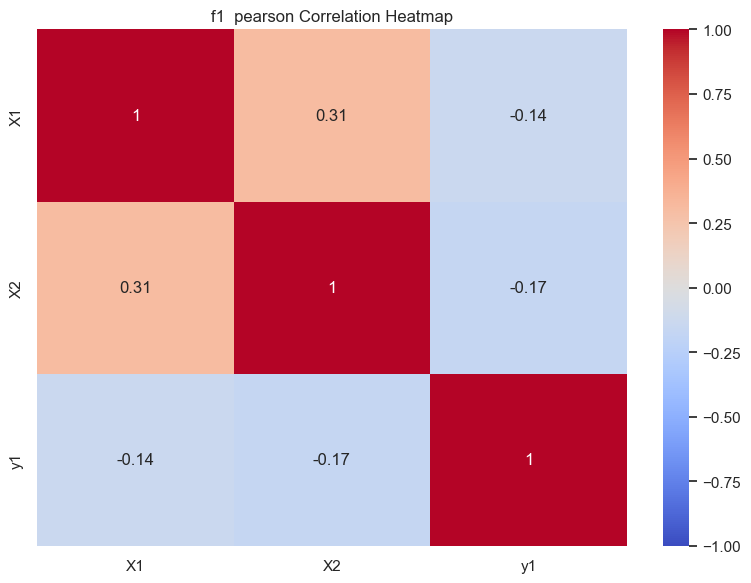


=== f2 Pearson Correlation Matrix ===


,X1,X2,y1
X1,1.000000,0.586287,0.751823
X2,0.586287,1.000000,0.390322
y1,0.751823,0.390322,1.000000


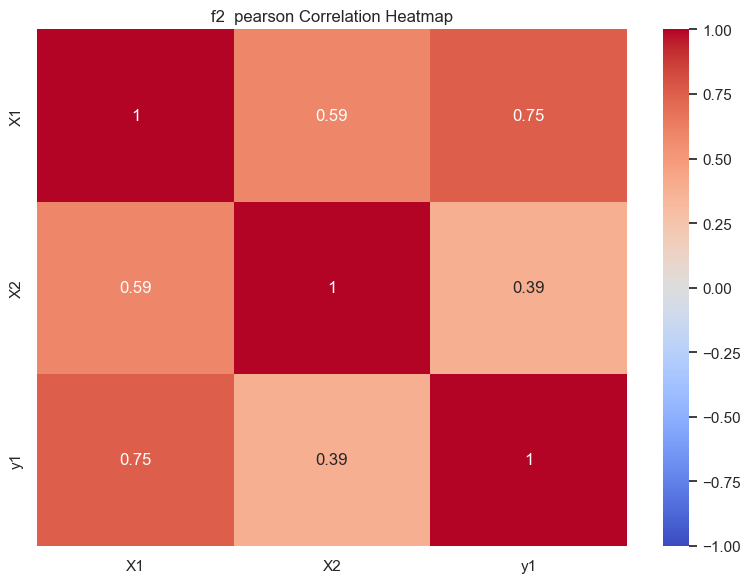


=== f3 Pearson Correlation Matrix ===


,X1,X2,X3,y1
X1,1.000000,0.393927,-0.133334,0.250607
X2,0.393927,1.000000,-0.305952,0.158439
X3,-0.133334,-0.305952,1.000000,-0.573676
y1,0.250607,0.158439,-0.573676,1.000000


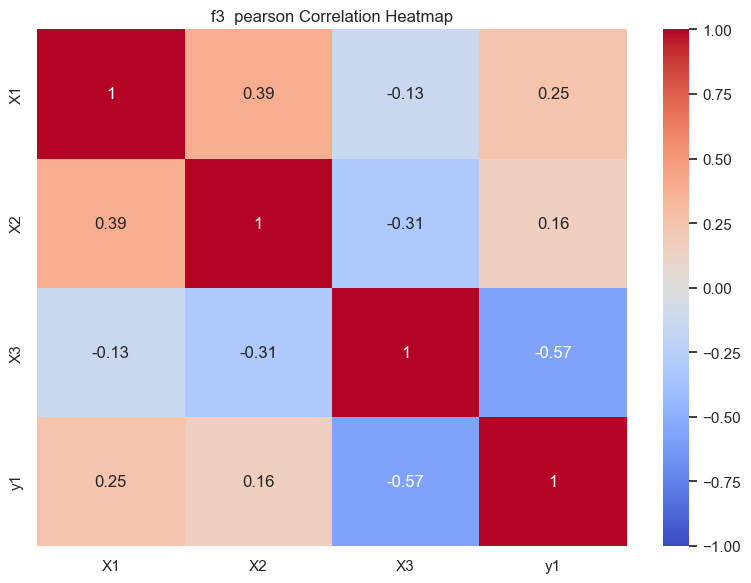


=== f4 Pearson Correlation Matrix ===


,X1,X2,X3,X4,y1
X1,1.000000,0.249329,0.249620,0.190186,-0.539888
X2,0.249329,1.000000,-0.080048,0.187999,-0.484809
X3,0.249620,-0.080048,1.000000,-0.154710,-0.084794
X4,0.190186,0.187999,-0.154710,1.000000,-0.532115
y1,-0.539888,-0.484809,-0.084794,-0.532115,1.000000


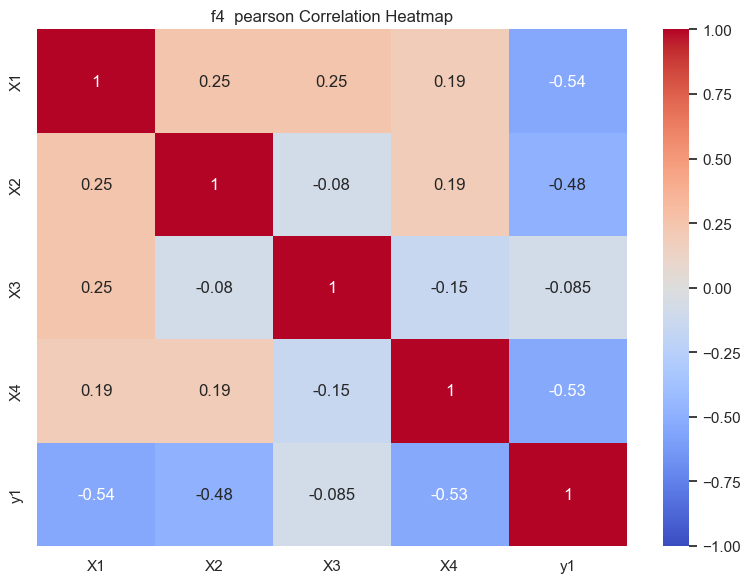


=== f5 Pearson Correlation Matrix ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.206791,-0.195190,0.069754,-0.284356
X2,-0.206791,1.000000,-0.145506,0.237412,0.389340
X3,-0.195190,-0.145506,1.000000,-0.149517,0.367304
X4,0.069754,0.237412,-0.149517,1.000000,0.569877
y1,-0.284356,0.389340,0.367304,0.569877,1.000000


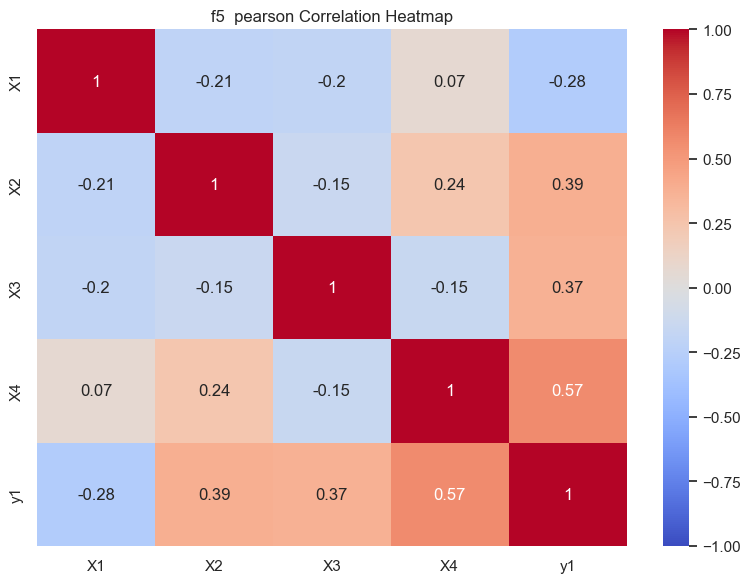


=== f6 Pearson Correlation Matrix ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.286008,-0.047450,0.173078,-0.443558,0.095408
X2,-0.286008,1.000000,0.316515,-0.143836,0.215755,-0.330443
X3,-0.047450,0.316515,1.000000,0.187253,-0.113127,0.258627
X4,0.173078,-0.143836,0.187253,1.000000,-0.207751,0.528466
X5,-0.443558,0.215755,-0.113127,-0.207751,1.000000,-0.584018
y1,0.095408,-0.330443,0.258627,0.528466,-0.584018,1.000000


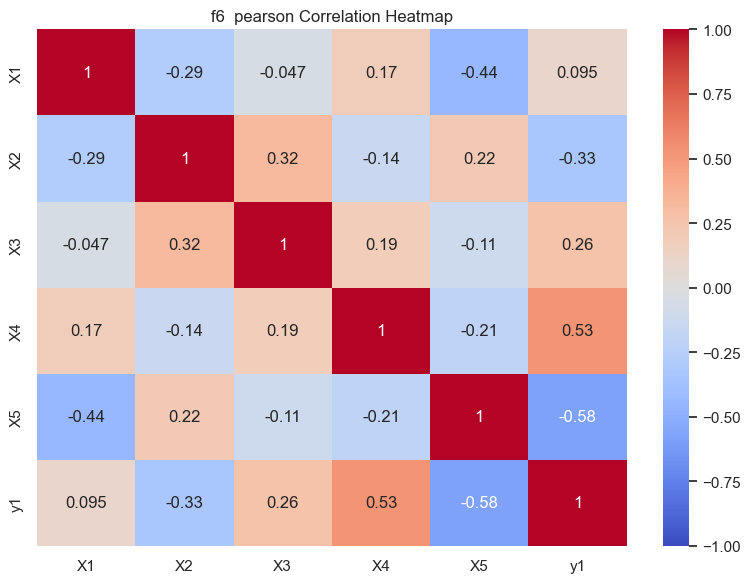


=== f7 Pearson Correlation Matrix ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.087820,-0.219735,-0.164804,-0.037565,-0.444499,-0.343224
X2,-0.087820,1.000000,-0.057662,0.159318,0.320656,0.199460,0.048185
X3,-0.219735,-0.057662,1.000000,0.216439,-0.303483,0.077832,0.177308
X4,-0.164804,0.159318,0.216439,1.000000,0.061882,0.063726,-0.075984
X5,-0.037565,0.320656,-0.303483,0.061882,1.000000,0.105690,-0.377932
X6,-0.444499,0.199460,0.077832,0.063726,0.105690,1.000000,0.307256
y1,-0.343224,0.048185,0.177308,-0.075984,-0.377932,0.307256,1.000000


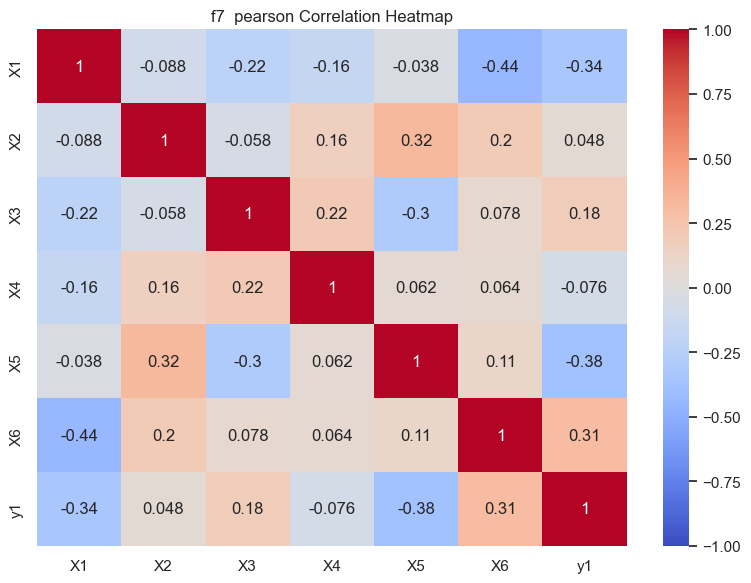


=== f8 Pearson Correlation Matrix ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.162617,0.030388,0.103208,0.284799,0.168195,0.161069,0.133306,-0.625861
X2,0.162617,1.000000,0.085355,-0.215134,0.073564,-0.019985,-0.208756,-0.281889,-0.235349
X3,0.030388,0.085355,1.000000,0.027322,-0.037170,-0.201629,-0.198264,0.005548,-0.622894
X4,0.103208,-0.215134,0.027322,1.000000,-0.044017,-0.111424,-0.109485,0.389955,-0.072546
X5,0.284799,0.073564,-0.037170,-0.044017,1.000000,0.086033,0.198886,0.054223,-0.169340
X6,0.168195,-0.019985,-0.201629,-0.111424,0.086033,1.000000,-0.031840,0.060149,0.067227
X7,0.161069,-0.208756,-0.198264,-0.109485,0.198886,-0.031840,1.000000,-0.142724,-0.289269
X8,0.133306,-0.281889,0.005548,0.389955,0.054223,0.060149,-0.142724,1.000000,0.053484
y1,-0.625861,-0.235349,-0.622894,-0.072546,-0.169340,0.067227,-0.289269,0.053484,1.000000


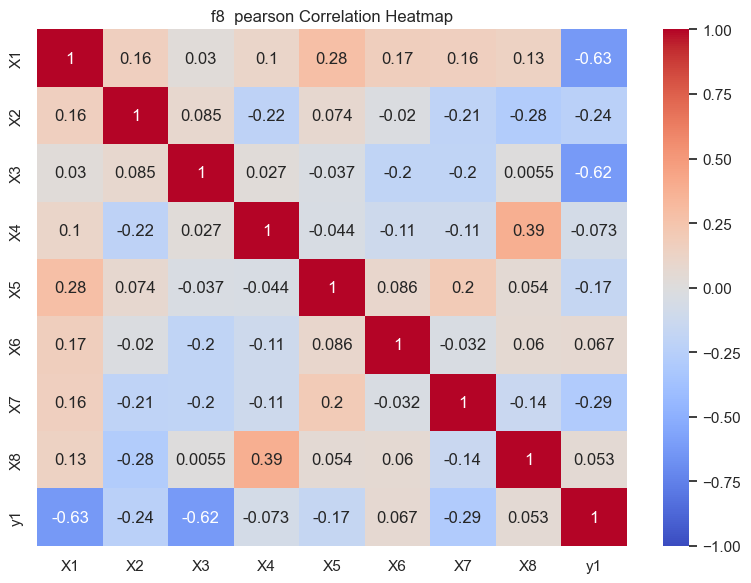

In [26]:
for name, df in functions_data.items():

    print(f"\n=== {name} Pearson Correlation Matrix ===")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()


=== f1 — Spearman Correlation ===


,X1,X2,y1
X1,1.000000,0.212121,0.357576
X2,0.212121,1.000000,0.684848
y1,0.357576,0.684848,1.000000


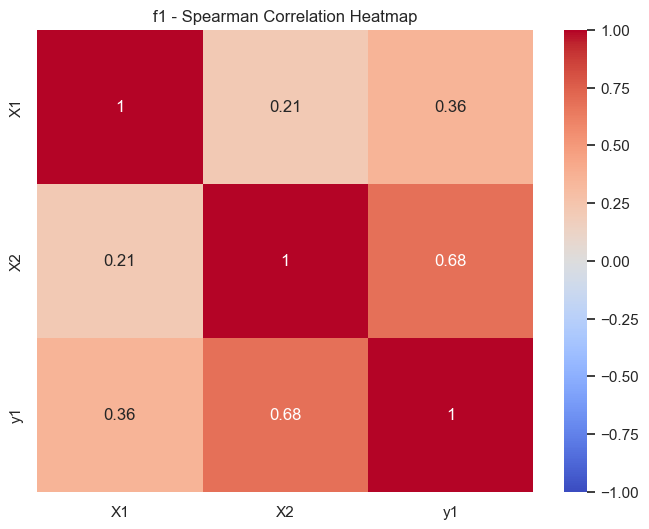


=== f2 — Spearman Correlation ===


,X1,X2,y1
X1,1.000000,0.612121,0.818182
X2,0.612121,1.000000,0.381818
y1,0.818182,0.381818,1.000000


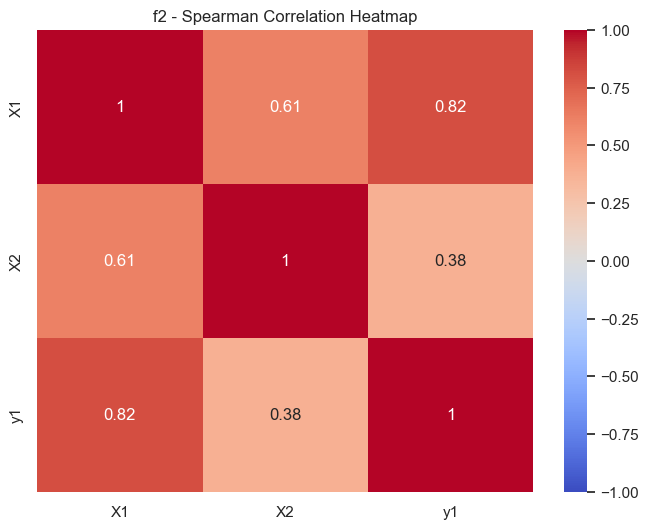


=== f3 — Spearman Correlation ===


,X1,X2,X3,y1
X1,1.000000,0.414286,-0.282143,0.103571
X2,0.414286,1.000000,-0.321429,0.310714
X3,-0.282143,-0.321429,1.000000,-0.228571
y1,0.103571,0.310714,-0.228571,1.000000


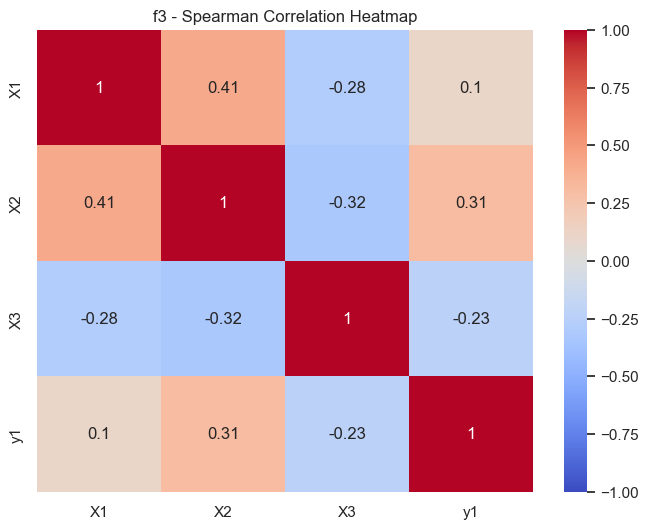


=== f4 — Spearman Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,0.246274,0.244939,0.184427,-0.569299
X2,0.246274,1.000000,-0.037152,0.163515,-0.469633
X3,0.244939,-0.037152,1.000000,-0.156841,-0.162180
X4,0.184427,0.163515,-0.156841,1.000000,-0.454060
y1,-0.569299,-0.469633,-0.162180,-0.454060,1.000000


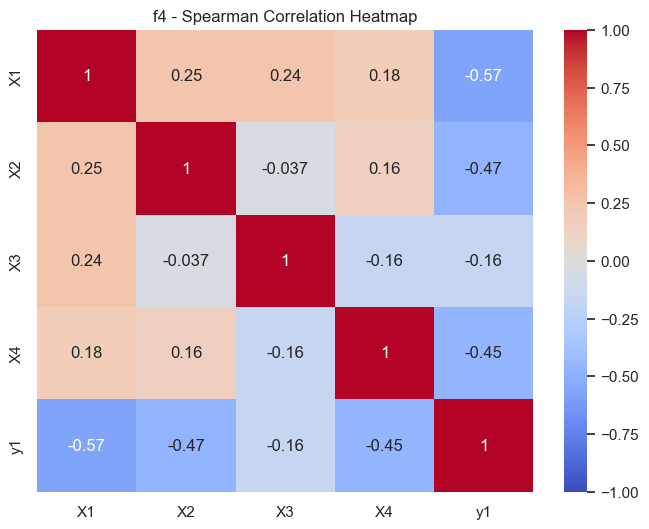


=== f5 — Spearman Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.249624,-0.166917,0.051128,-0.142857
X2,-0.249624,1.000000,-0.051128,0.249624,0.153383
X3,-0.166917,-0.051128,1.000000,-0.163910,0.270677
X4,0.051128,0.249624,-0.163910,1.000000,0.577444
y1,-0.142857,0.153383,0.270677,0.577444,1.000000


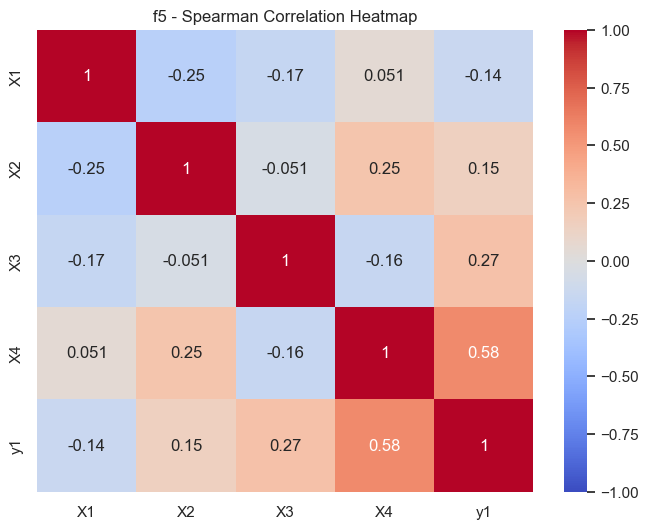


=== f6 — Spearman Correlation ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.227068,-0.004511,0.180451,-0.425564,-0.010526
X2,-0.227068,1.000000,0.242105,-0.073684,0.126316,-0.178947
X3,-0.004511,0.242105,1.000000,0.234586,-0.221053,0.231579
X4,0.180451,-0.073684,0.234586,1.000000,-0.264662,0.553383
X5,-0.425564,0.126316,-0.221053,-0.264662,1.000000,-0.621053
y1,-0.010526,-0.178947,0.231579,0.553383,-0.621053,1.000000


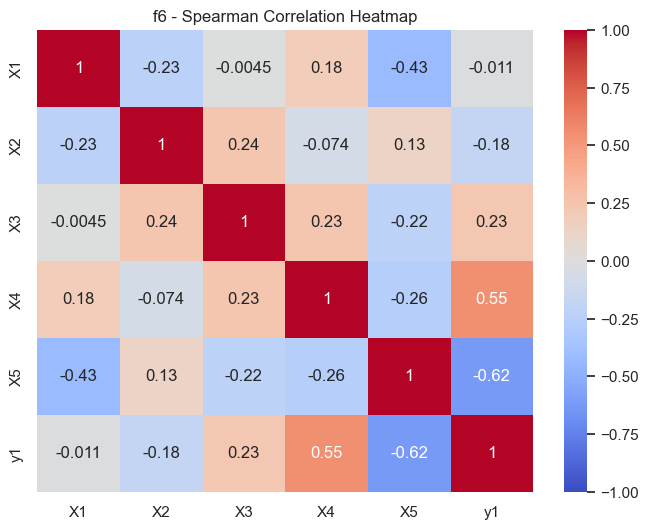


=== f7 — Spearman Correlation ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.153281,-0.191991,-0.175528,-0.064294,-0.413126,-0.285873
X2,-0.153281,1.000000,-0.048276,0.172414,0.325918,0.183092,-0.091435
X3,-0.191991,-0.048276,1.000000,0.132369,-0.302336,0.124805,0.324583
X4,-0.175528,0.172414,0.132369,1.000000,0.047386,0.119021,-0.091880
X5,-0.064294,0.325918,-0.302336,0.047386,1.000000,0.071858,-0.453615
X6,-0.413126,0.183092,0.124805,0.119021,0.071858,1.000000,0.190211
y1,-0.285873,-0.091435,0.324583,-0.091880,-0.453615,0.190211,1.000000


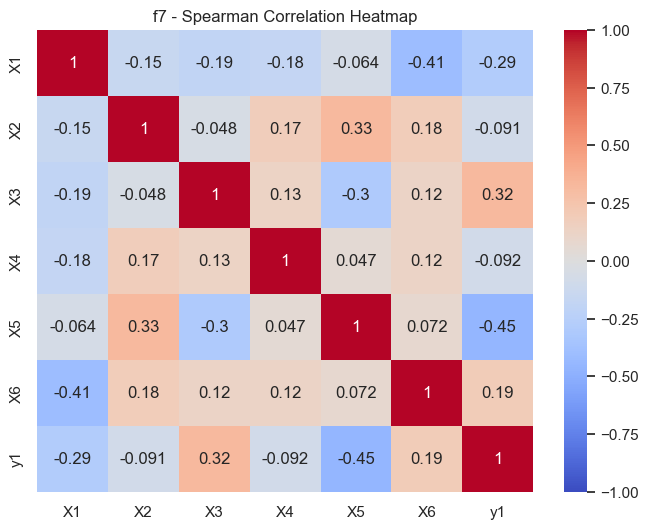


=== f8 — Spearman Correlation ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.167355,-0.009006,0.099437,0.296811,0.199062,0.171107,0.129456,-0.607317
X2,0.167355,1.000000,0.079550,-0.214447,0.048030,-0.025328,-0.199625,-0.288931,-0.232645
X3,-0.009006,0.079550,1.000000,0.053471,-0.032083,-0.162101,-0.194371,-0.032083,-0.583114
X4,0.099437,-0.214447,0.053471,1.000000,-0.075610,-0.137899,-0.089118,0.367917,-0.112383
X5,0.296811,0.048030,-0.032083,-0.075610,1.000000,0.129456,0.210694,0.026266,-0.119512
X6,0.199062,-0.025328,-0.162101,-0.137899,0.129456,1.000000,-0.000938,0.106567,0.007880
X7,0.171107,-0.199625,-0.194371,-0.089118,0.210694,-0.000938,1.000000,-0.127392,-0.302251
X8,0.129456,-0.288931,-0.032083,0.367917,0.026266,0.106567,-0.127392,1.000000,0.045216
y1,-0.607317,-0.232645,-0.583114,-0.112383,-0.119512,0.007880,-0.302251,0.045216,1.000000


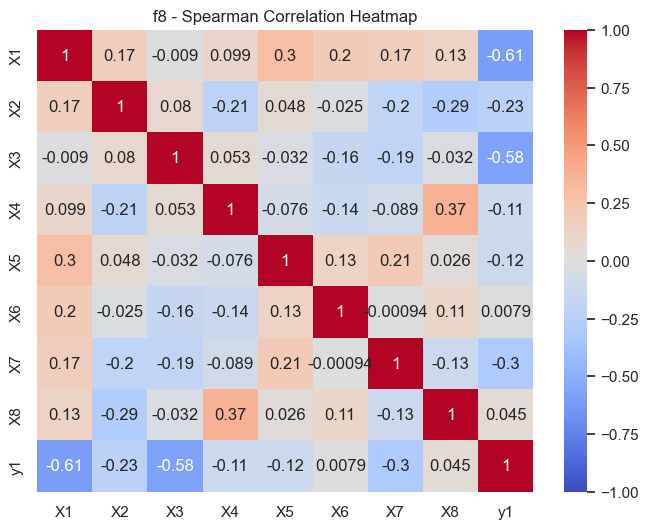

In [27]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Spearman Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()


=== f1 — Kendall Correlation ===


,X1,X2,y1
X1,1.000000,0.111111,0.244444
X2,0.111111,1.000000,0.511111
y1,0.244444,0.511111,1.000000


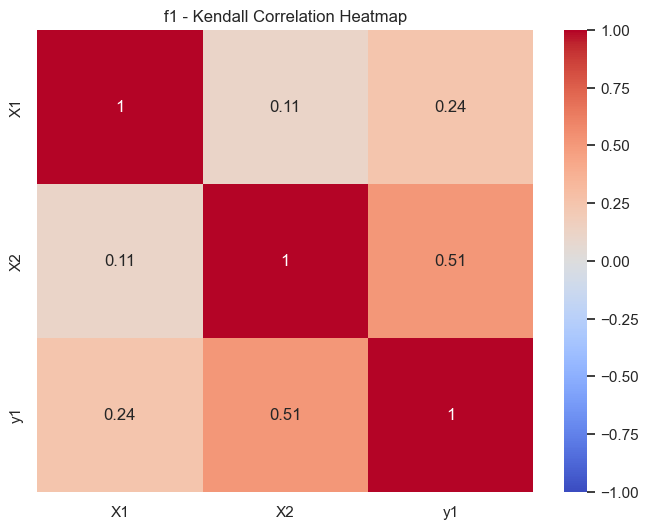


=== f2 — Kendall Correlation ===


,X1,X2,y1
X1,1.000000,0.422222,0.644444
X2,0.422222,1.000000,0.333333
y1,0.644444,0.333333,1.000000


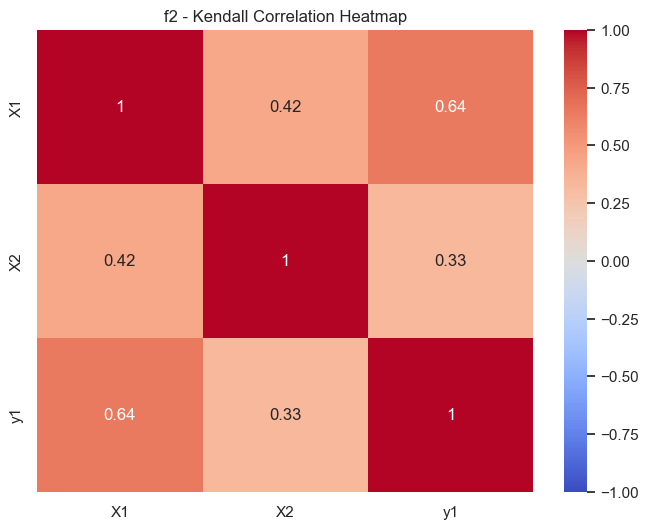


=== f3 — Kendall Correlation ===


,X1,X2,X3,y1
X1,1.000000,0.276190,-0.219048,0.066667
X2,0.276190,1.000000,-0.257143,0.219048
X3,-0.219048,-0.257143,1.000000,-0.161905
y1,0.066667,0.219048,-0.161905,1.000000


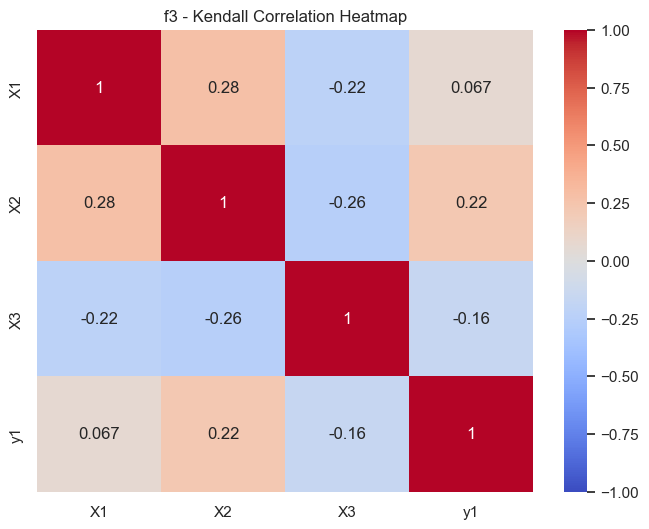


=== f4 — Kendall Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,0.181609,0.181609,0.144828,-0.402299
X2,0.181609,1.000000,-0.029885,0.108046,-0.337931
X3,0.181609,-0.029885,1.000000,-0.112644,-0.144828
X4,0.144828,0.108046,-0.112644,1.000000,-0.328736
y1,-0.402299,-0.337931,-0.144828,-0.328736,1.000000


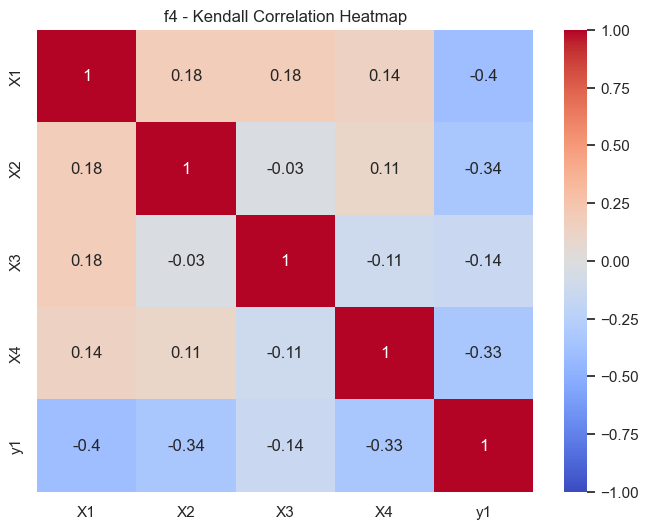


=== f5 — Kendall Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.178947,-0.136842,0.042105,-0.136842
X2,-0.178947,1.000000,-0.052632,0.147368,0.073684
X3,-0.136842,-0.052632,1.000000,-0.126316,0.200000
X4,0.042105,0.147368,-0.126316,1.000000,0.400000
y1,-0.136842,0.073684,0.200000,0.400000,1.000000


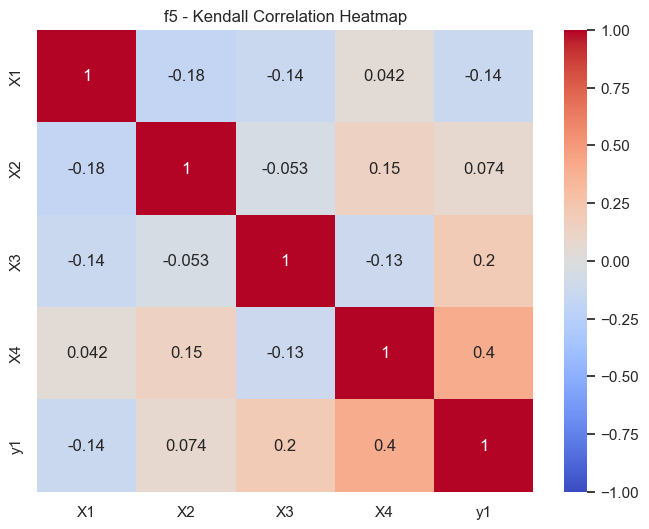


=== f6 — Kendall Correlation ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.189474,-0.010526,0.147368,-0.315789,0.010526
X2,-0.189474,1.000000,0.189474,-0.052632,0.073684,-0.126316
X3,-0.010526,0.189474,1.000000,0.168421,-0.105263,0.157895
X4,0.147368,-0.052632,0.168421,1.000000,-0.221053,0.378947
X5,-0.315789,0.073684,-0.105263,-0.221053,1.000000,-0.421053
y1,0.010526,-0.126316,0.157895,0.378947,-0.421053,1.000000


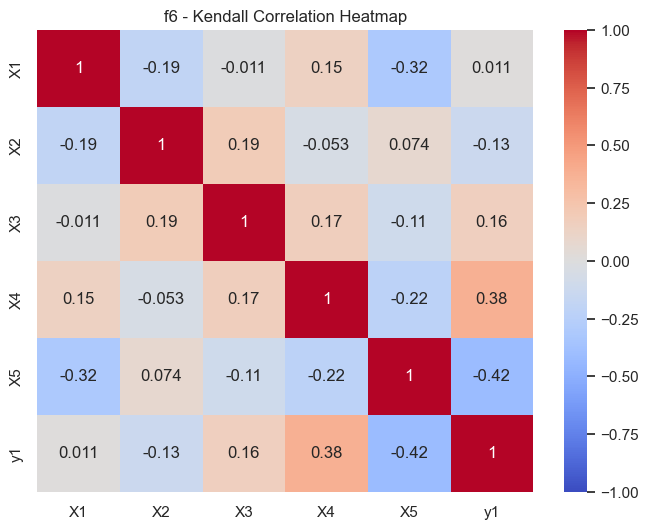


=== f7 — Kendall Correlation ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.071264,-0.135632,-0.126437,-0.080460,-0.273563,-0.245977
X2,-0.071264,1.000000,-0.039080,0.117241,0.227586,0.108046,-0.085057
X3,-0.135632,-0.039080,1.000000,0.062069,-0.195402,0.098851,0.218391
X4,-0.126437,0.117241,0.062069,1.000000,0.025287,0.052874,-0.075862
X5,-0.080460,0.227586,-0.195402,0.025287,1.000000,0.071264,-0.305747
X6,-0.273563,0.108046,0.098851,0.052874,0.071264,1.000000,0.135632
y1,-0.245977,-0.085057,0.218391,-0.075862,-0.305747,0.135632,1.000000


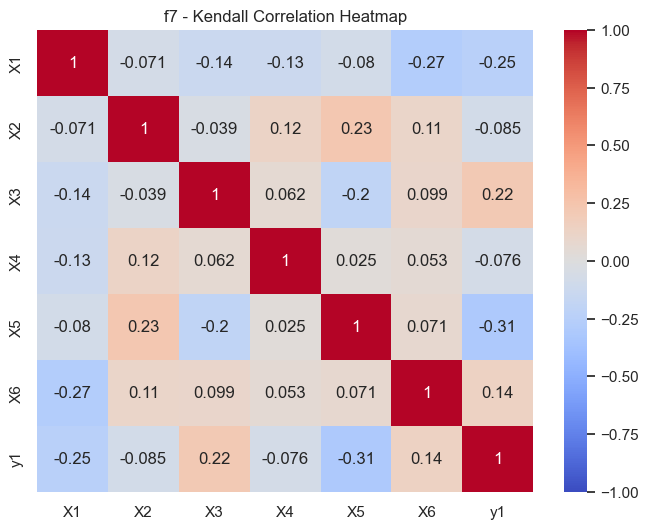


=== f8 — Kendall Correlation ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.125641,-0.041026,0.056410,0.200000,0.115385,0.092308,0.082051,-0.433333
X2,0.125641,1.000000,0.053846,-0.171795,0.043590,-0.046154,-0.151282,-0.187179,-0.153846
X3,-0.041026,0.053846,1.000000,0.015385,-0.020513,-0.110256,-0.117949,-0.025641,-0.417949
X4,0.056410,-0.171795,0.015385,1.000000,-0.051282,-0.064103,-0.056410,0.266667,-0.079487
X5,0.200000,0.043590,-0.020513,-0.051282,1.000000,0.089744,0.143590,0.025641,-0.069231
X6,0.115385,-0.046154,-0.110256,-0.064103,0.089744,1.000000,0.002564,0.064103,-0.005128
X7,0.092308,-0.151282,-0.117949,-0.056410,0.143590,0.002564,1.000000,-0.087179,-0.233333
X8,0.082051,-0.187179,-0.025641,0.266667,0.025641,0.064103,-0.087179,1.000000,0.038462
y1,-0.433333,-0.153846,-0.417949,-0.079487,-0.069231,-0.005128,-0.233333,0.038462,1.000000


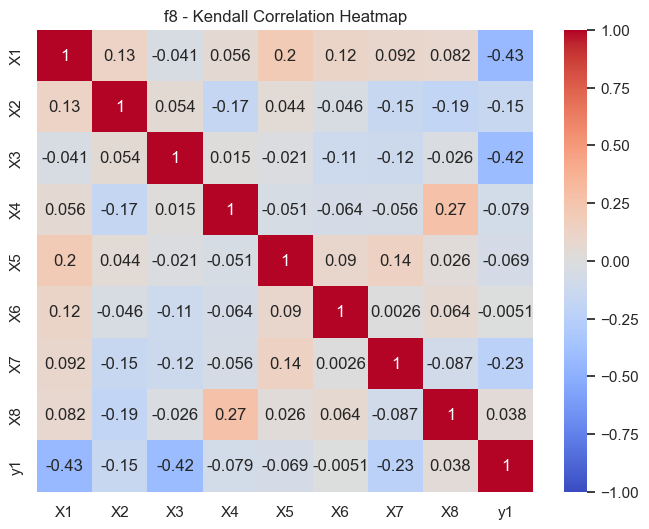

In [28]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Kendall Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


In [29]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n=== {name} — Mutual Information with Output ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



=== f1 — Mutual Information with Output ===


,Feature,Mutual_Info
0,X1,0
1,X2,0



=== f2 — Mutual Information with Output ===


,Feature,Mutual_Info
0,X1,0.303968
1,X2,0.077302



=== f3 — Mutual Information with Output ===


...

,Feature,Mutual_Info
4,X5,0.114804
3,X4,0.050748
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



=== f7 — Mutual Information with Output ===


,Feature,Mutual_Info
4,X5,0.159403
5,X6,0.094584
3,X4,0.064966
0,X1,0.050784
1,X2,0.000000
2,X3,0.000000



=== f8 — Mutual Information with Output ===


,Feature,Mutual_Info
2,X3,0.263916
0,X1,0.253348
6,X7,0.098503
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


In [34]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n=== {name} — Partial Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)


  Using cached pingouin-0.5.5-py3-none-any.whl.metadata (19 kB)
  Using cached pandas_flavor-0.8.1-py3-none-any.whl.metadata (6.6 kB)
Using cached pingouin-0.5.5-py3-none-any.whl (204 kB)
Using cached pandas_flavor-0.8.1-py3-none-any.whl (8.5 kB)

=== f1 — Partial Correlation ===
          n         r          CI95%     p-val
pearson  10 -0.091436  [-0.71, 0.61]  0.815021
          n         r          CI95%     p-val
pearson  10 -0.134221  [-0.73, 0.58]  0.730638

=== f2 — Partial Correlation ===
          n         r         CI95%    p-val
pearson  10  0.701194  [0.07, 0.93]  0.03532
          n        r          CI95%     p-val
pearson  10 -0.09447  [-0.71, 0.61]  0.808972

=== f3 — Partial Correlation ===
          n         r         CI95%     p-val
pearson  15  0.240196  [-0.36, 0.7]  0.429262
          n        r          CI95%     p-val
pearson  15 -0.11281  [-0.62, 0.47]  0.713669
          n         r           CI95%     p-val
pearson  15 -0.568084  [-0.85, -0.02]  0.042822



## 5. Scatter Plots for All Functions
- For feature vs target scatters, visualize how inputs relate to output.



=== Feature vs Output Plots for f1 ===
X shape for f1: (10, 2)
y shape for f1: (10,)


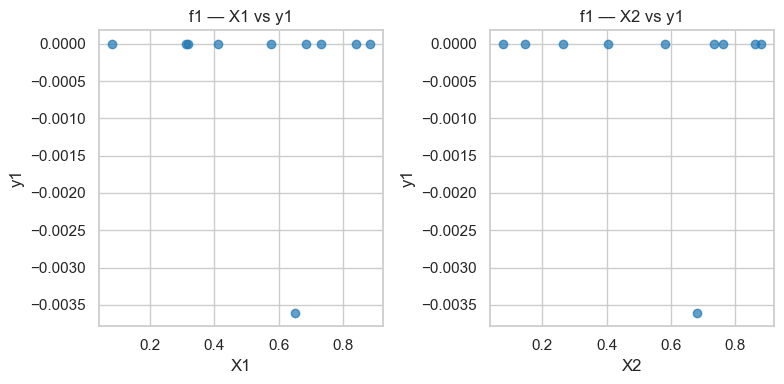


=== Feature vs Output Plots for f2 ===
X shape for f2: (10, 2)
y shape for f2: (10,)


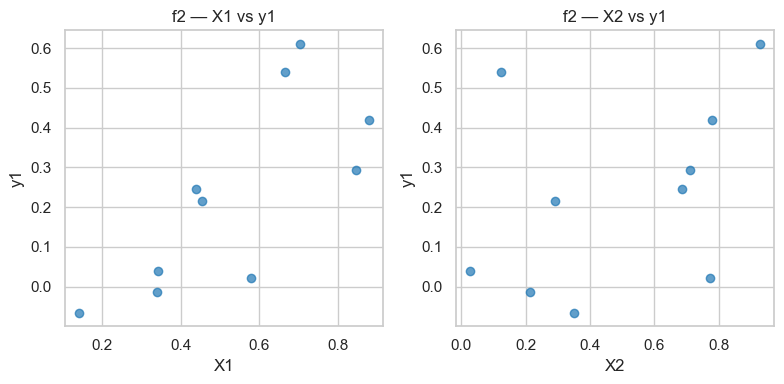


=== Feature vs Output Plots for f3 ===
X shape for f3: (15, 3)
y shape for f3: (15,)


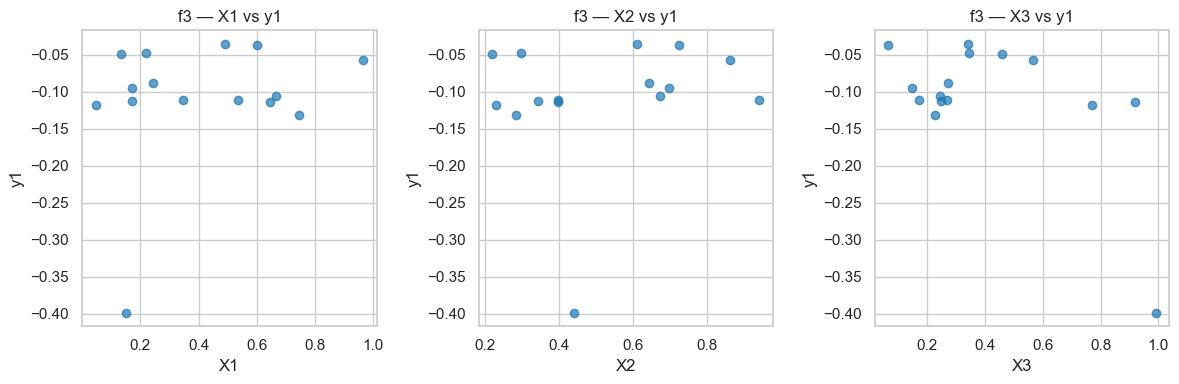


=== Feature vs Output Plots for f4 ===
X shape for f4: (30, 4)
y shape for f4: (30,)


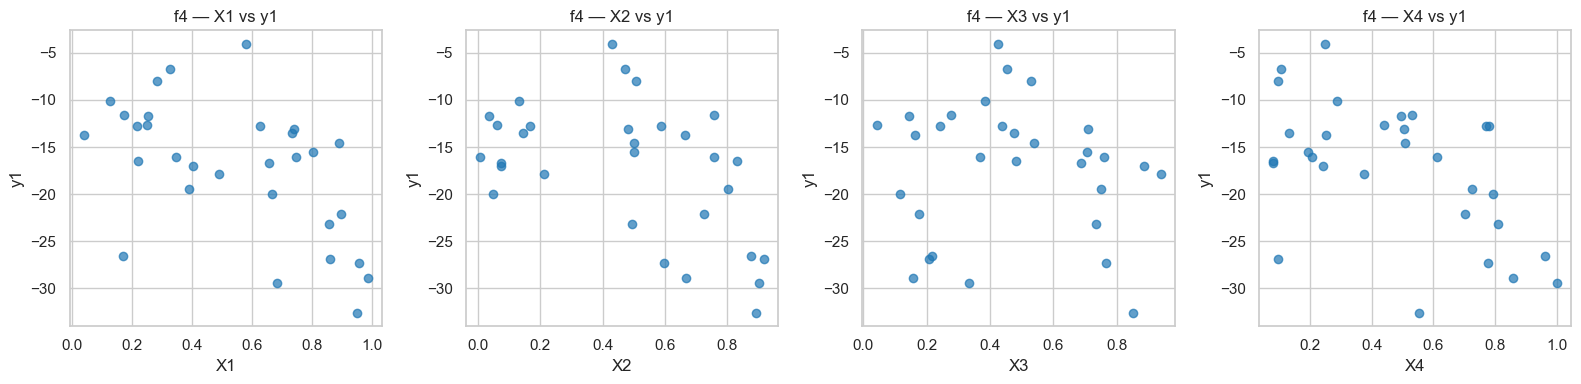


=== Feature vs Output Plots for f5 ===
X shape for f5: (20, 4)
y shape for f5: (20,)


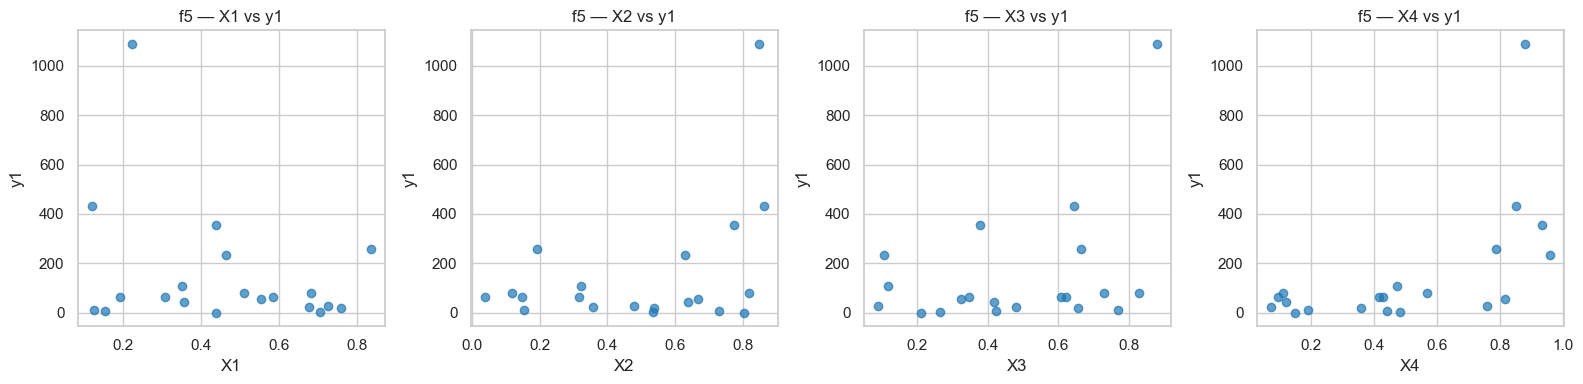


=== Feature vs Output Plots for f6 ===
X shape for f6: (20, 5)
y shape for f6: (20,)


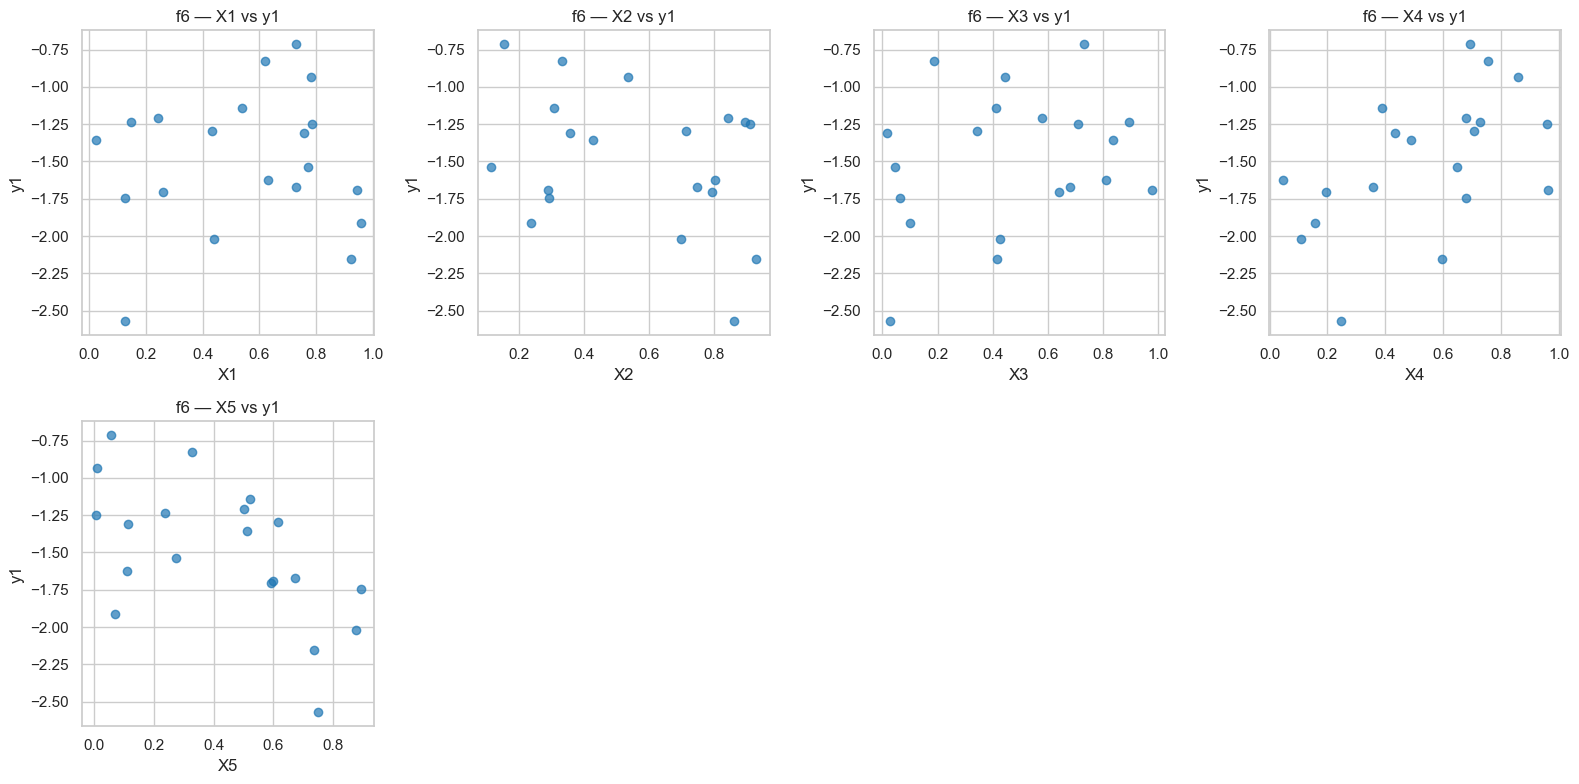


=== Feature vs Output Plots for f7 ===
X shape for f7: (30, 6)
y shape for f7: (30,)


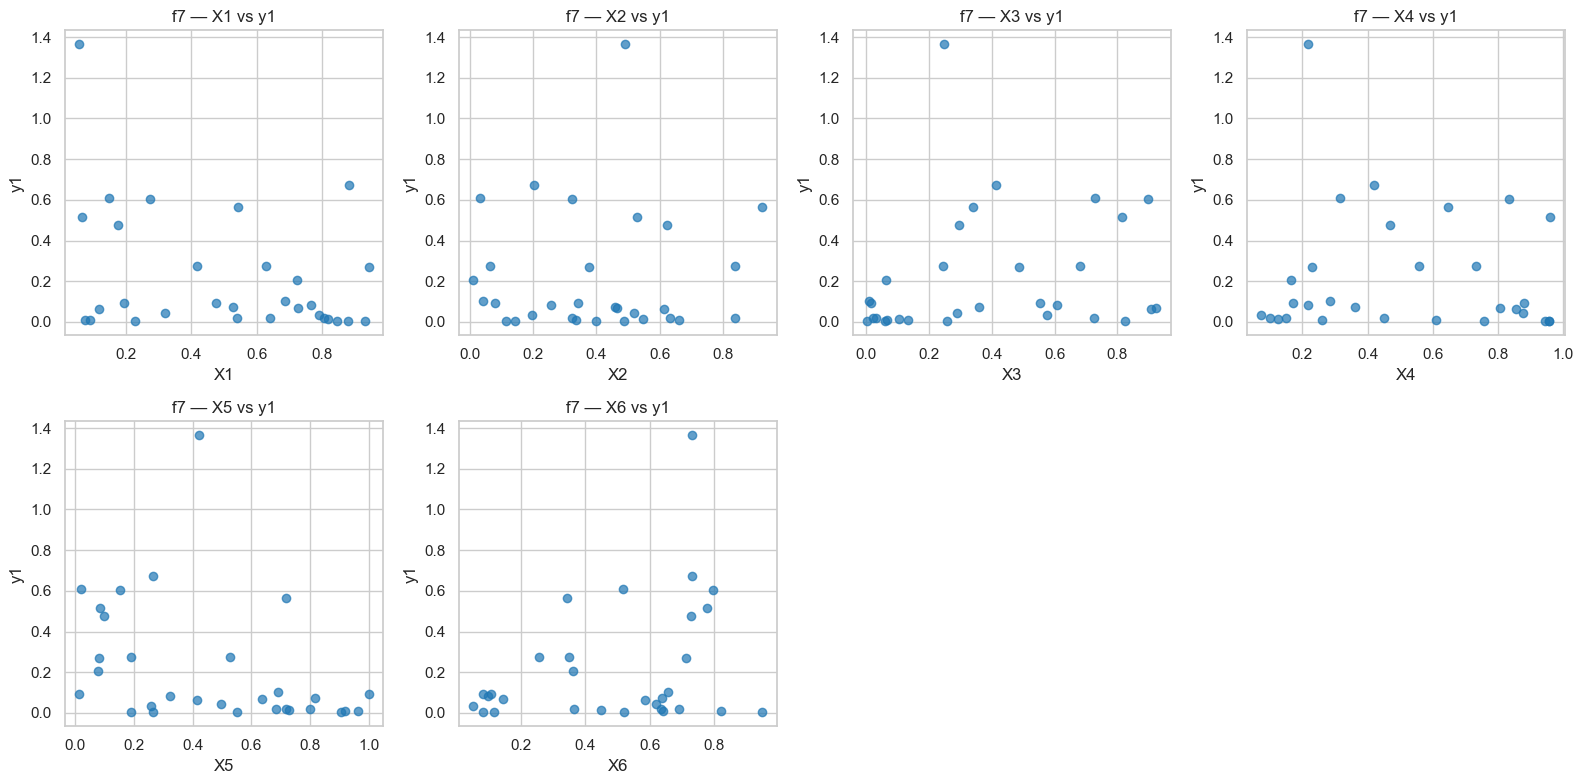


=== Feature vs Output Plots for f8 ===
X shape for f8: (40, 8)
y shape for f8: (40,)


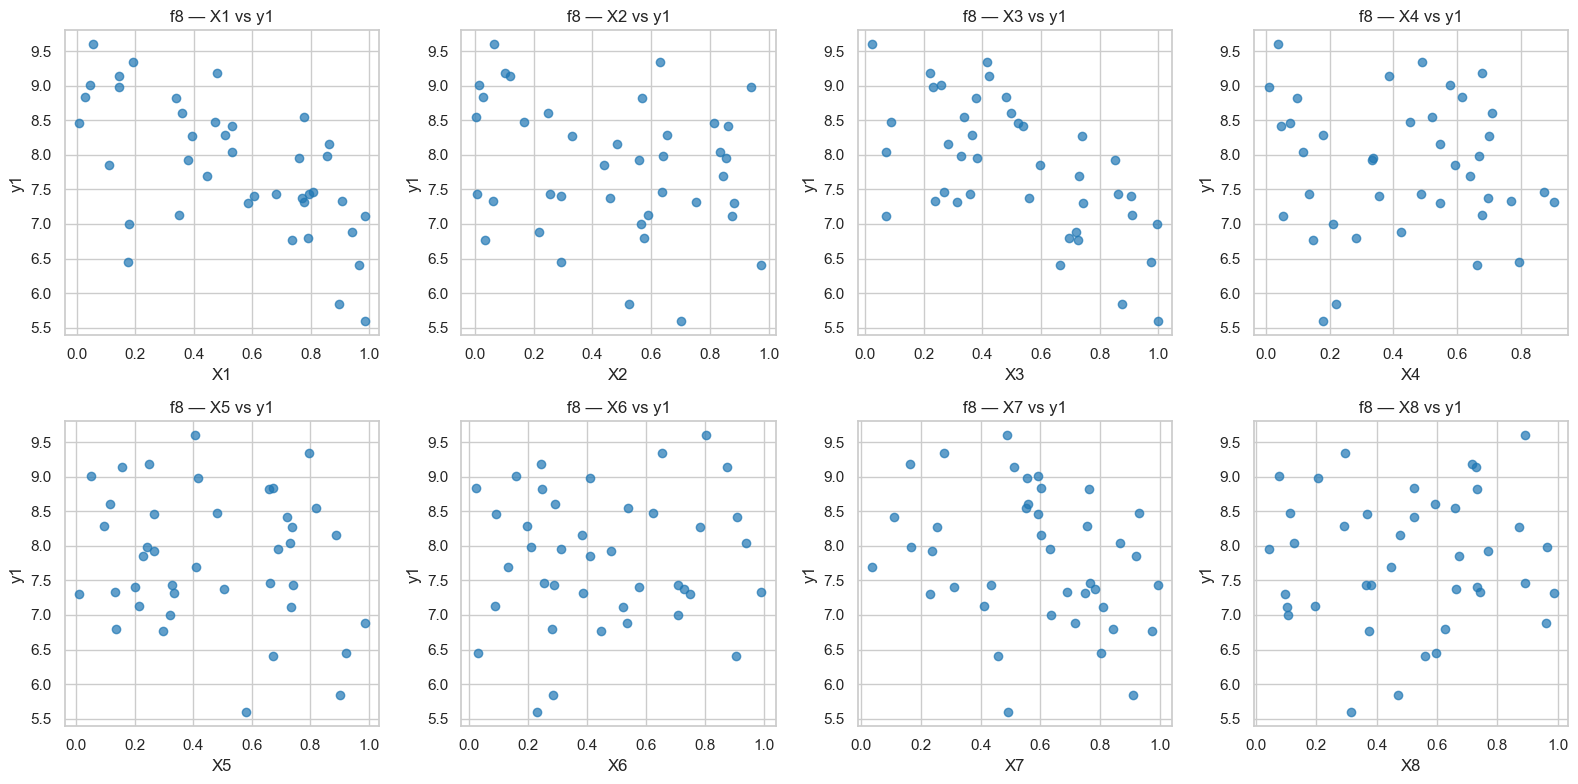

In [24]:
for name, df in functions_data.items():

    print(f"\n=== Feature vs Output Plots for {name} ===")

    # -----------------------
    # 1. Extract input/output columns
    # -----------------------
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot

    # -----------------------
    # 2. Sanity checks
    # -----------------------
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"

    # -----------------------
    # 3. Plot each feature vs y
    # -----------------------
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


## 6. Distribution Analysis
- Understand the distribution of functios.
- Check for skewness, multimodality, or extreme values.


=== f1 — Feature & Output Distributions ===


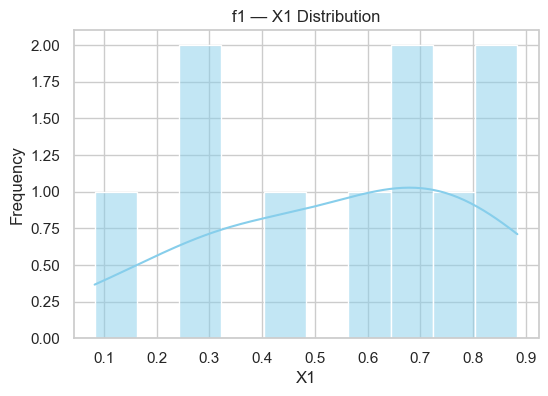

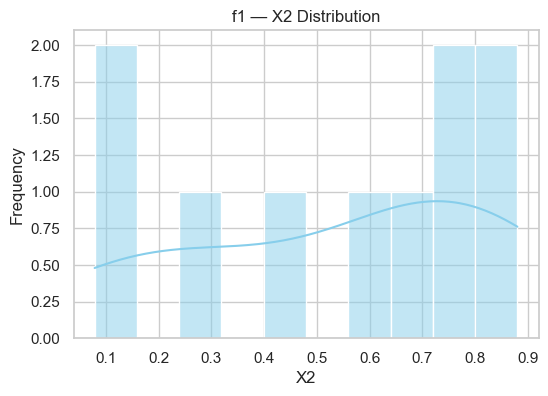

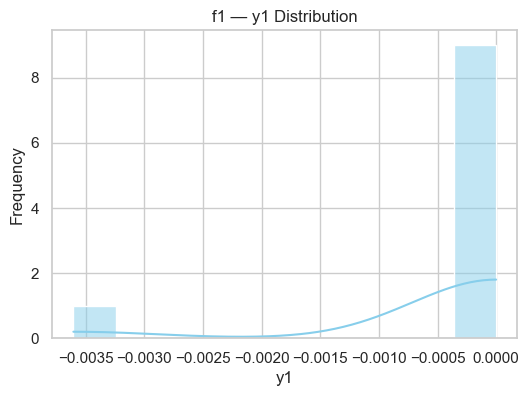


=== f2 — Feature & Output Distributions ===


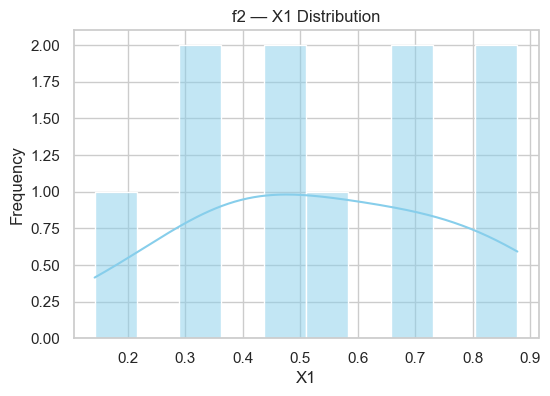

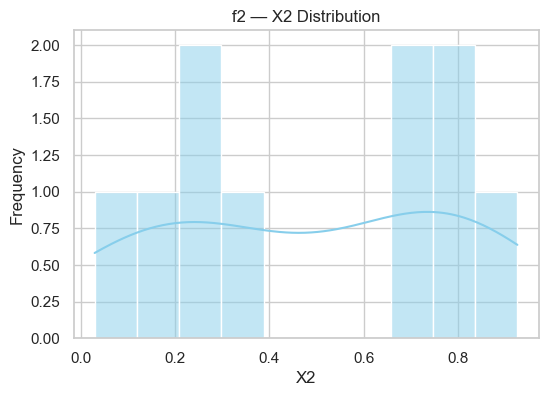

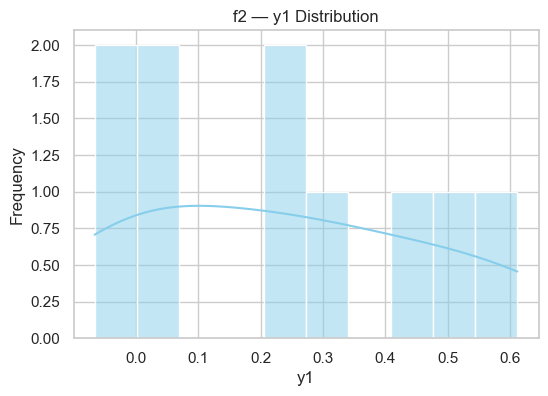


=== f3 — Feature & Output Distributions ===


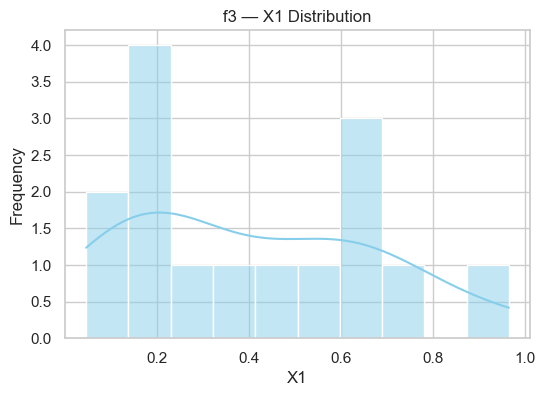

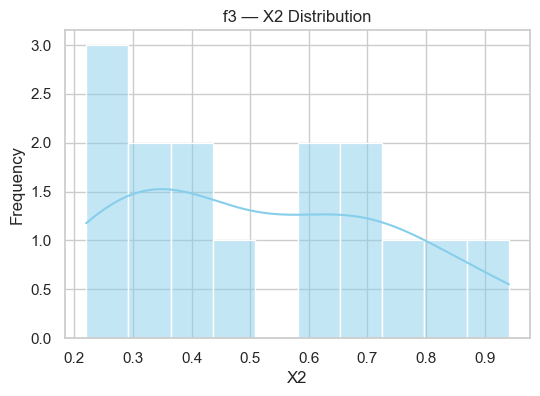

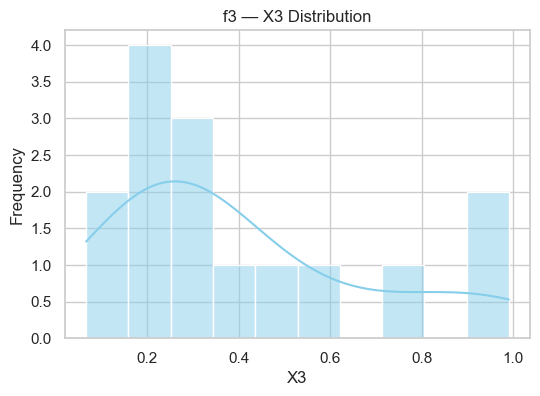

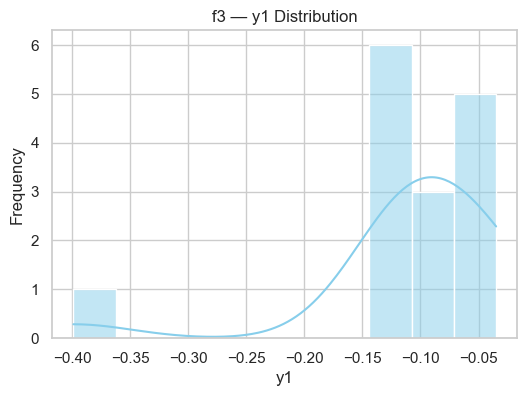


=== f4 — Feature & Output Distributions ===


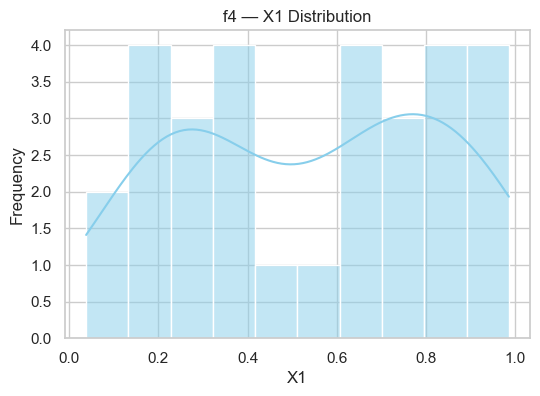

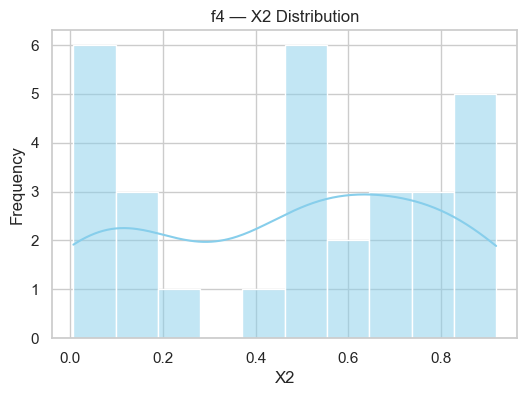

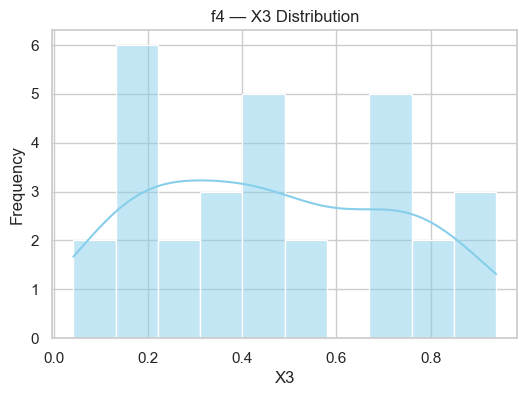

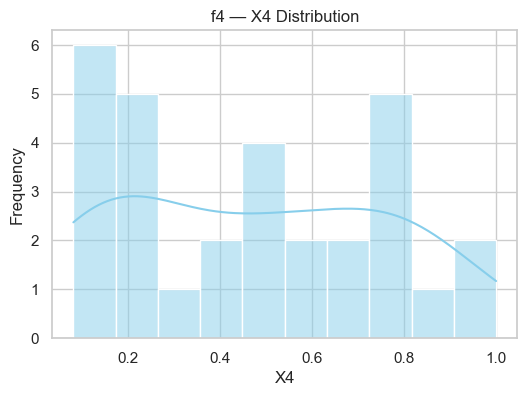

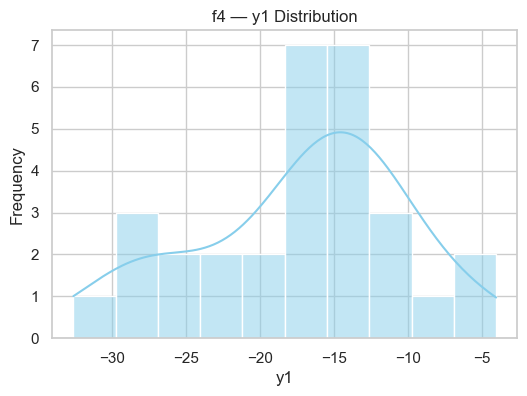


=== f5 — Feature & Output Distributions ===


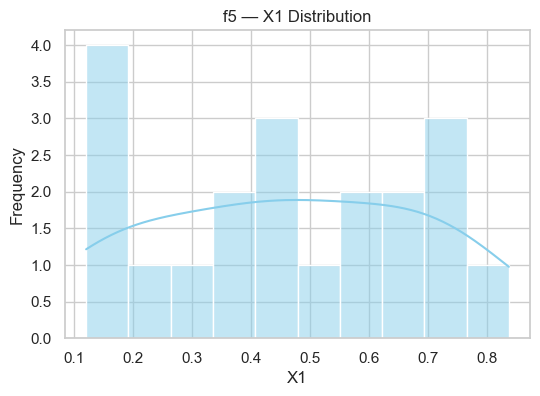

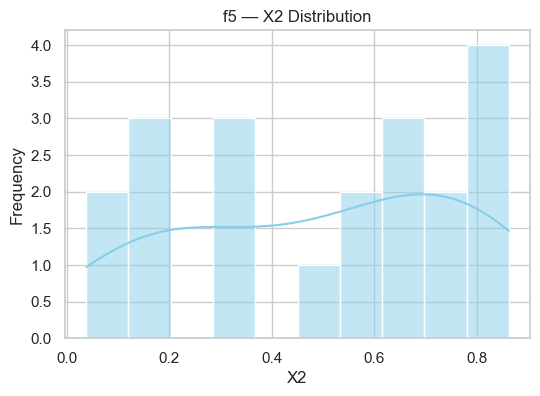

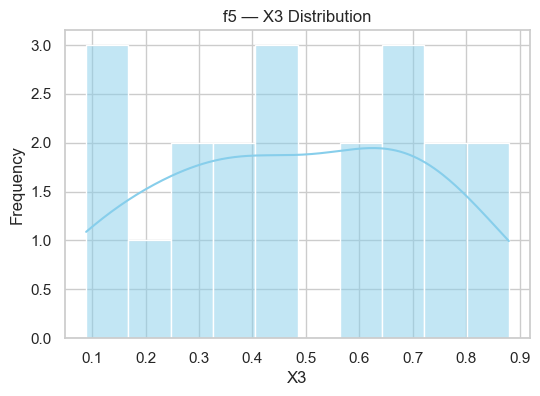

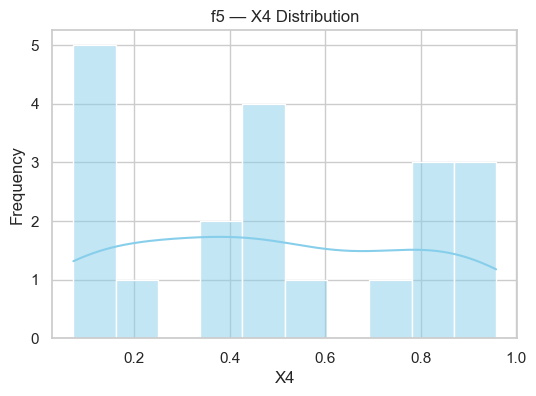

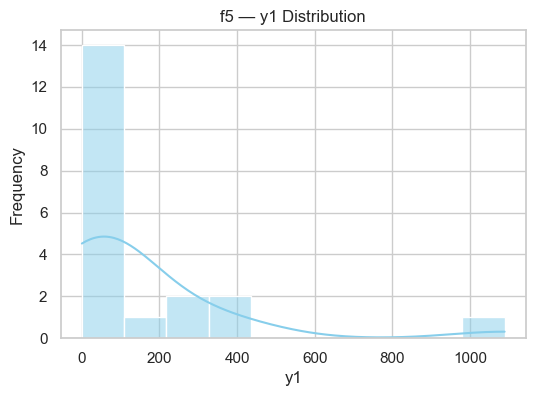


=== f6 — Feature & Output Distributions ===


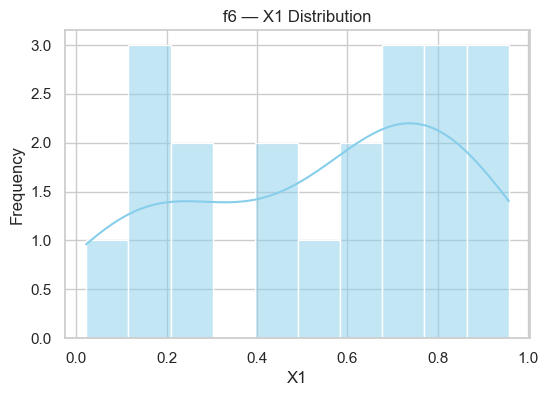

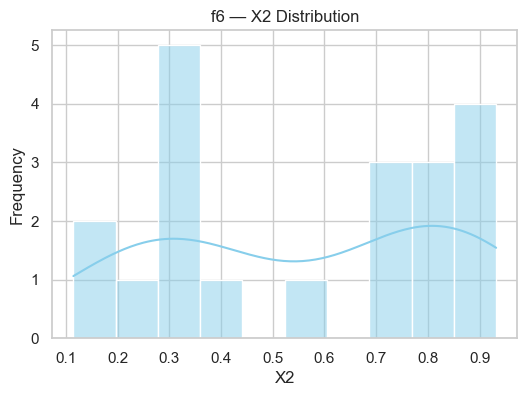

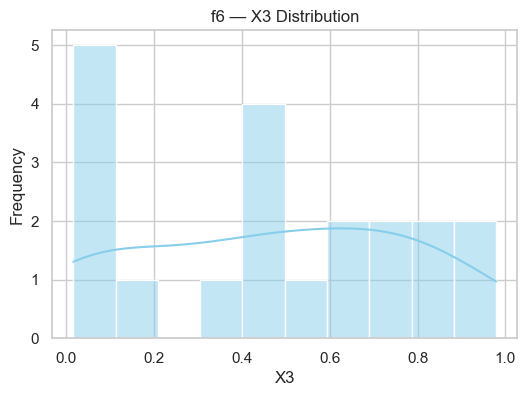

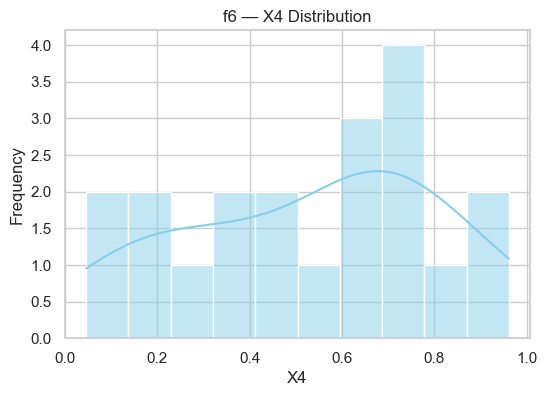

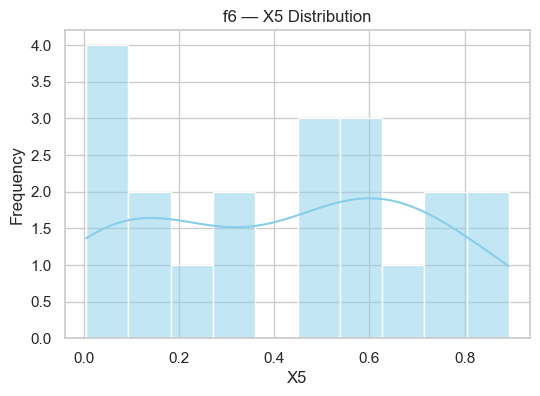

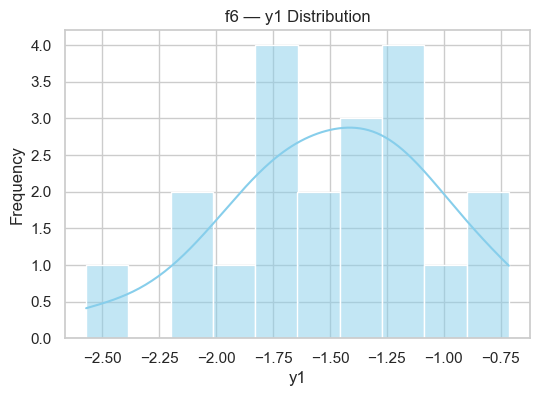


=== f7 — Feature & Output Distributions ===


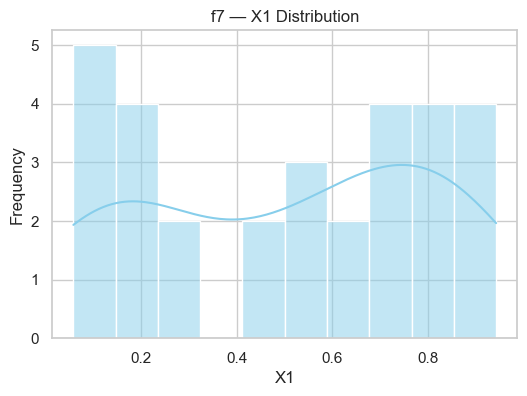

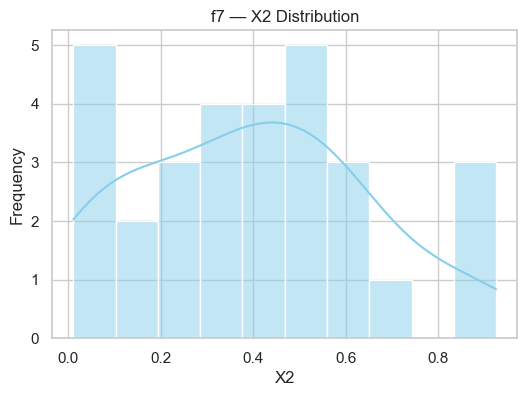

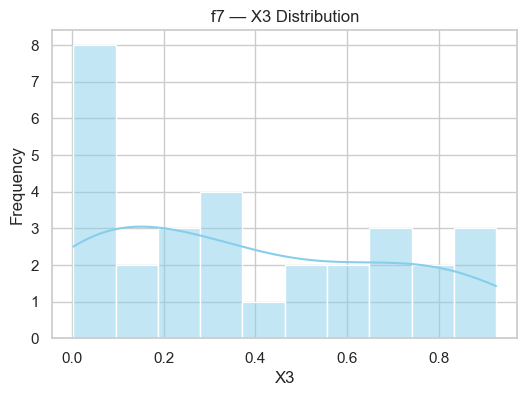

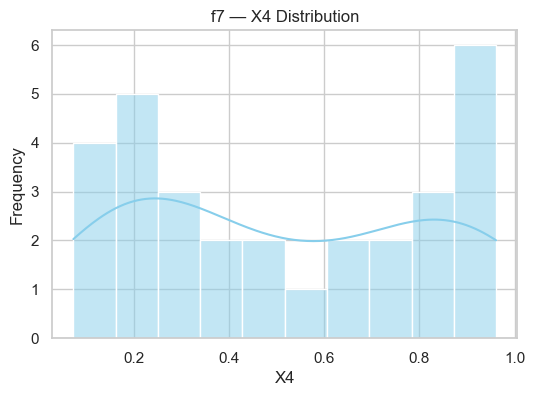

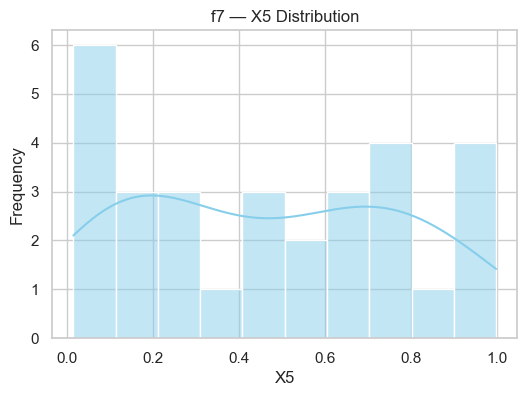

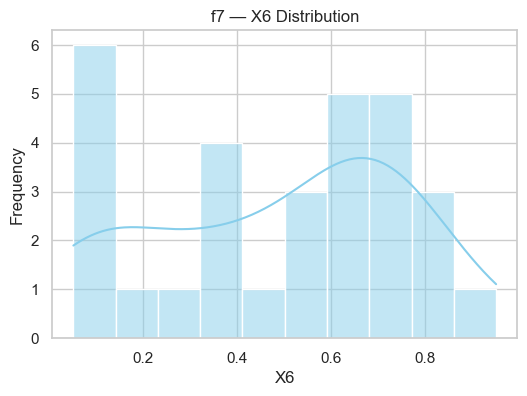

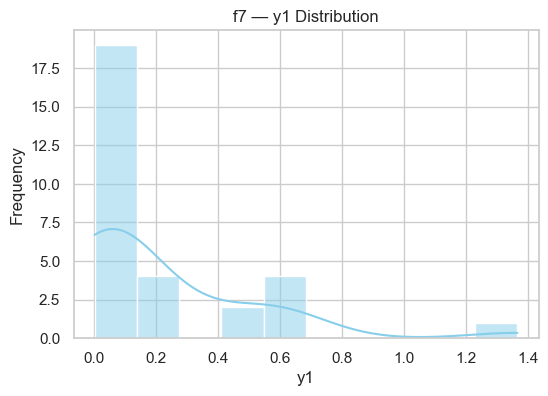


=== f8 — Feature & Output Distributions ===


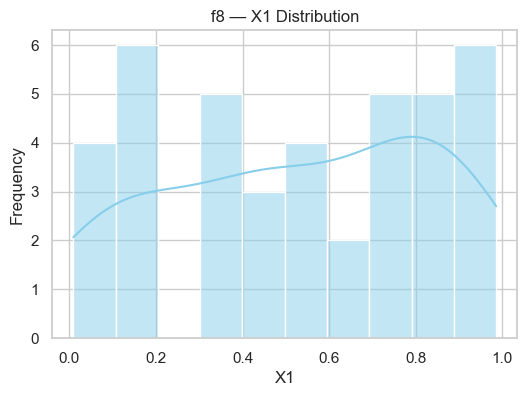

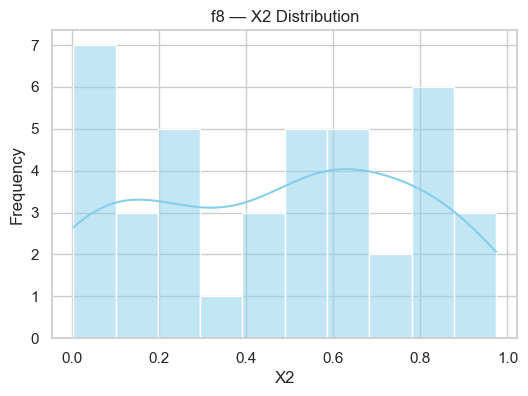

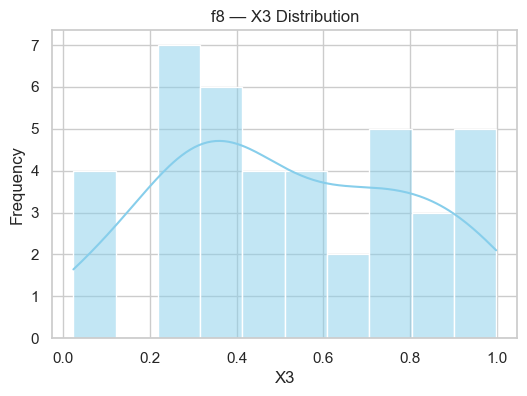

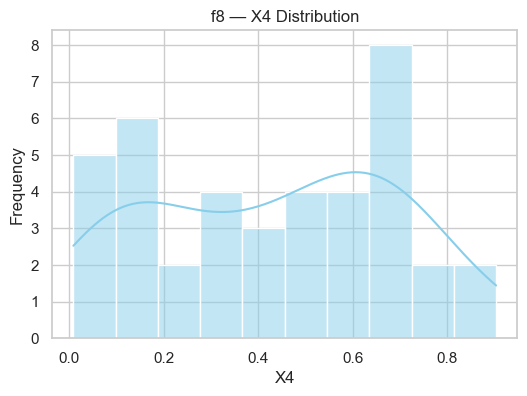

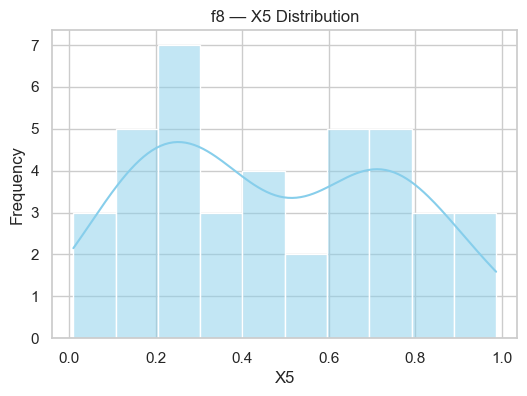

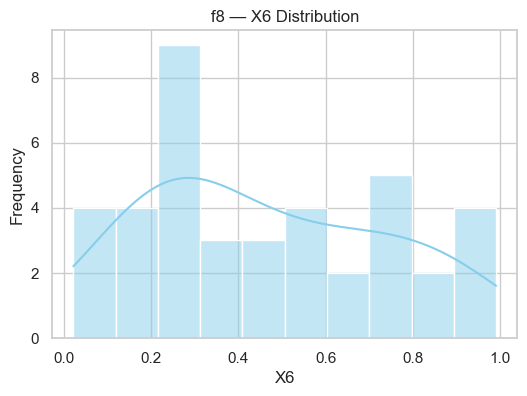

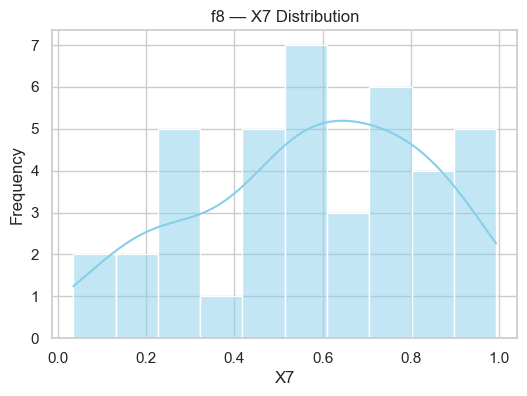

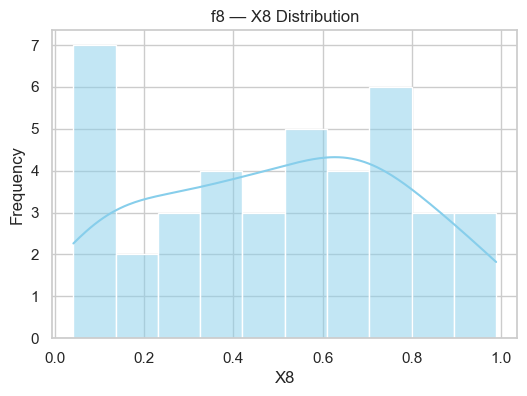

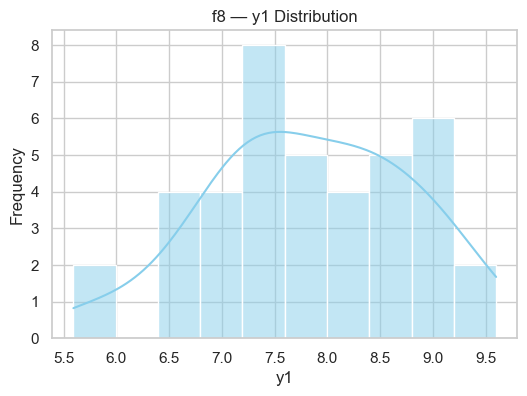

In [37]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Feature & Output Distributions ===")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()
